# Diabetes Prediction Model Training with Decision Tree

**Algorithm:** Decision Tree Classifier  
**Dataset:** diabetes.csv (50,000 patient records)  
**Target:** Binary Classification (0 = No Diabetes, 1 = Diabetes)

## Steps:
1. Import Libraries
2. Load Dataset
3. Exploratory Data Analysis (EDA)
4. Data Preprocessing
5. Train-Test Split
6. Model Training (Decision Tree)
7. Model Evaluation & Accuracy
8. Save Model


## Step 1: Import Libraries


In [1]:
import pandas as pd
import numpy as np
import os
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score
from sklearn.tree import DecisionTreeClassifier
import joblib

# For EDA visualization
try:
    import matplotlib.pyplot as plt
    import seaborn as sns
    plt.style.use('seaborn-v0_8')
    VISUALIZATION_AVAILABLE = True
    print("SUCCESS: All libraries imported! (with visualization support)")
except ImportError:
    VISUALIZATION_AVAILABLE = False
    print("SUCCESS: All libraries imported! (visualization not available)")


SUCCESS: All libraries imported! (with visualization support)


## Step 2: Load Dataset


In [2]:
# Load diabetes dataset
dataset_path = 'diabetes.csv'

if os.path.exists(dataset_path):
    print(f"Loading dataset: {dataset_path}")
    df = pd.read_csv(dataset_path)
    
    print(f"\nSUCCESS: Dataset loaded!")
    print(f"   Rows: {df.shape[0]:,}")
    print(f"   Columns: {df.shape[1]}")
    print(f"\nColumn names:")
    print(df.columns.tolist())
    print(f"\nFirst 5 rows:")
    print(df.head())
    print(f"\nDataset Info:")
    print(df.info())
else:
    print(f"ERROR: {dataset_path} not found!")


Loading dataset: diabetes.csv

SUCCESS: Dataset loaded!
   Rows: 50,000
   Columns: 9

Column names:
['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']

First 5 rows:
   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6    148.0           72.0           35.0      0.0  33.6   
1            1     85.0           66.0           29.0      0.0  26.6   
2            8    183.0           64.0            0.0      0.0  23.3   
3            1     89.0           66.0           23.0     94.0  28.1   
4            0    137.0           40.0           35.0    168.0  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeInde

## Step 3: Exploratory Data Analysis (EDA)


In [3]:
# EDA - Dataset Information
print("="*70)
print("DATASET INFORMATION")
print("="*70)
print(f"\nShape: {df.shape}")
print(f"\nData Types:")
print(df.dtypes)
print(f"\nMissing Values:")
print(df.isnull().sum())
print(f"\nDuplicate Rows: {df.duplicated().sum()}")


DATASET INFORMATION

Shape: (50000, 9)

Data Types:
Pregnancies                   int64
Glucose                     float64
BloodPressure               float64
SkinThickness               float64
Insulin                     float64
BMI                         float64
DiabetesPedigreeFunction    float64
Age                           int64
Outcome                       int64
dtype: object

Missing Values:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

Duplicate Rows: 0


In [4]:
# EDA - Basic Statistics
print("="*70)
print("BASIC STATISTICS")
print("="*70)
print(df.describe())


BASIC STATISTICS
        Pregnancies       Glucose  BloodPressure  SkinThickness       Insulin  \
count  50000.000000  50000.000000   50000.000000   50000.000000  50000.000000   
mean       3.631640    121.015678      69.649238      21.400154     95.972122   
std        2.946965     31.435118      18.307110      14.673372     91.876633   
min        0.000000      0.000000       0.000000       0.000000      0.000000   
25%        1.000000     99.200000      56.000000       9.900000      1.900000   
50%        3.000000    120.900000      69.200000      20.700000     78.900000   
75%        6.000000    142.700000      82.200000      31.400000    156.100000   
max       17.000000    199.000000     122.000000      99.000000    846.000000   

                BMI  DiabetesPedigreeFunction          Age       Outcome  
count  50000.000000              50000.000000  50000.00000  50000.000000  
mean      32.005120                  0.489790     33.73038      0.076880  
std        7.797371         

TARGET VARIABLE DISTRIBUTION (Outcome)

Counts:
Outcome
0    46156
1     3844
Name: count, dtype: int64

Percentages:
Outcome
0    92.312
1     7.688
Name: proportion, dtype: float64


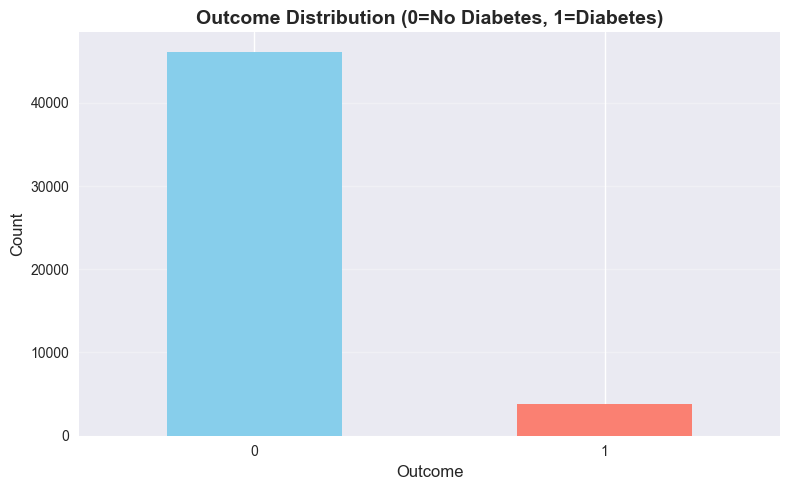

In [5]:
# EDA - Target Variable Distribution
print("="*70)
print("TARGET VARIABLE DISTRIBUTION (Outcome)")
print("="*70)
outcome_counts = df['Outcome'].value_counts()
outcome_percent = df['Outcome'].value_counts(normalize=True) * 100

print(f"\nCounts:")
print(outcome_counts)
print(f"\nPercentages:")
print(outcome_percent)

if VISUALIZATION_AVAILABLE:
    plt.figure(figsize=(8, 5))
    outcome_counts.plot(kind='bar', color=['skyblue', 'salmon'])
    plt.title('Outcome Distribution (0=No Diabetes, 1=Diabetes)', fontsize=14, fontweight='bold')
    plt.xlabel('Outcome', fontsize=12)
    plt.ylabel('Count', fontsize=12)
    plt.xticks(rotation=0)
    plt.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()


CORRELATION WITH TARGET VARIABLE

Correlation with Outcome:
Outcome                     1.000000
Glucose                     0.324901
BMI                         0.244821
BloodPressure               0.124269
Age                         0.085537
Pregnancies                 0.048021
DiabetesPedigreeFunction    0.013939
SkinThickness               0.008832
Insulin                     0.002284
Name: Outcome, dtype: float64


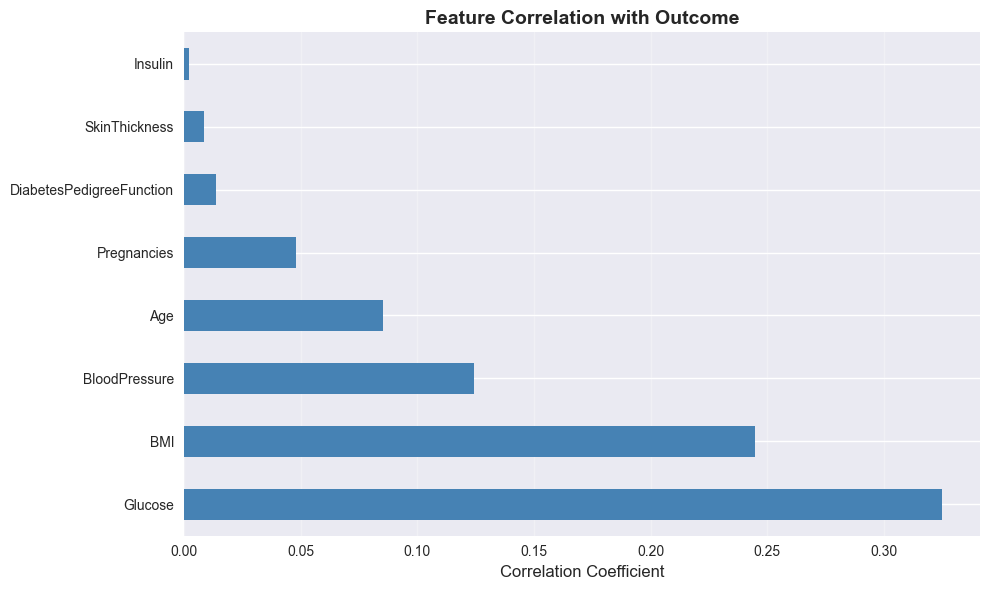

In [6]:
# EDA - Correlation Analysis
print("="*70)
print("CORRELATION WITH TARGET VARIABLE")
print("="*70)
correlations = df.corr()['Outcome'].sort_values(ascending=False)
print("\nCorrelation with Outcome:")
print(correlations)

if VISUALIZATION_AVAILABLE:
    plt.figure(figsize=(10, 6))
    correlations.drop('Outcome').plot(kind='barh', color='steelblue')
    plt.title('Feature Correlation with Outcome', fontsize=14, fontweight='bold')
    plt.xlabel('Correlation Coefficient', fontsize=12)
    plt.grid(axis='x', alpha=0.3)
    plt.tight_layout()
    plt.show()


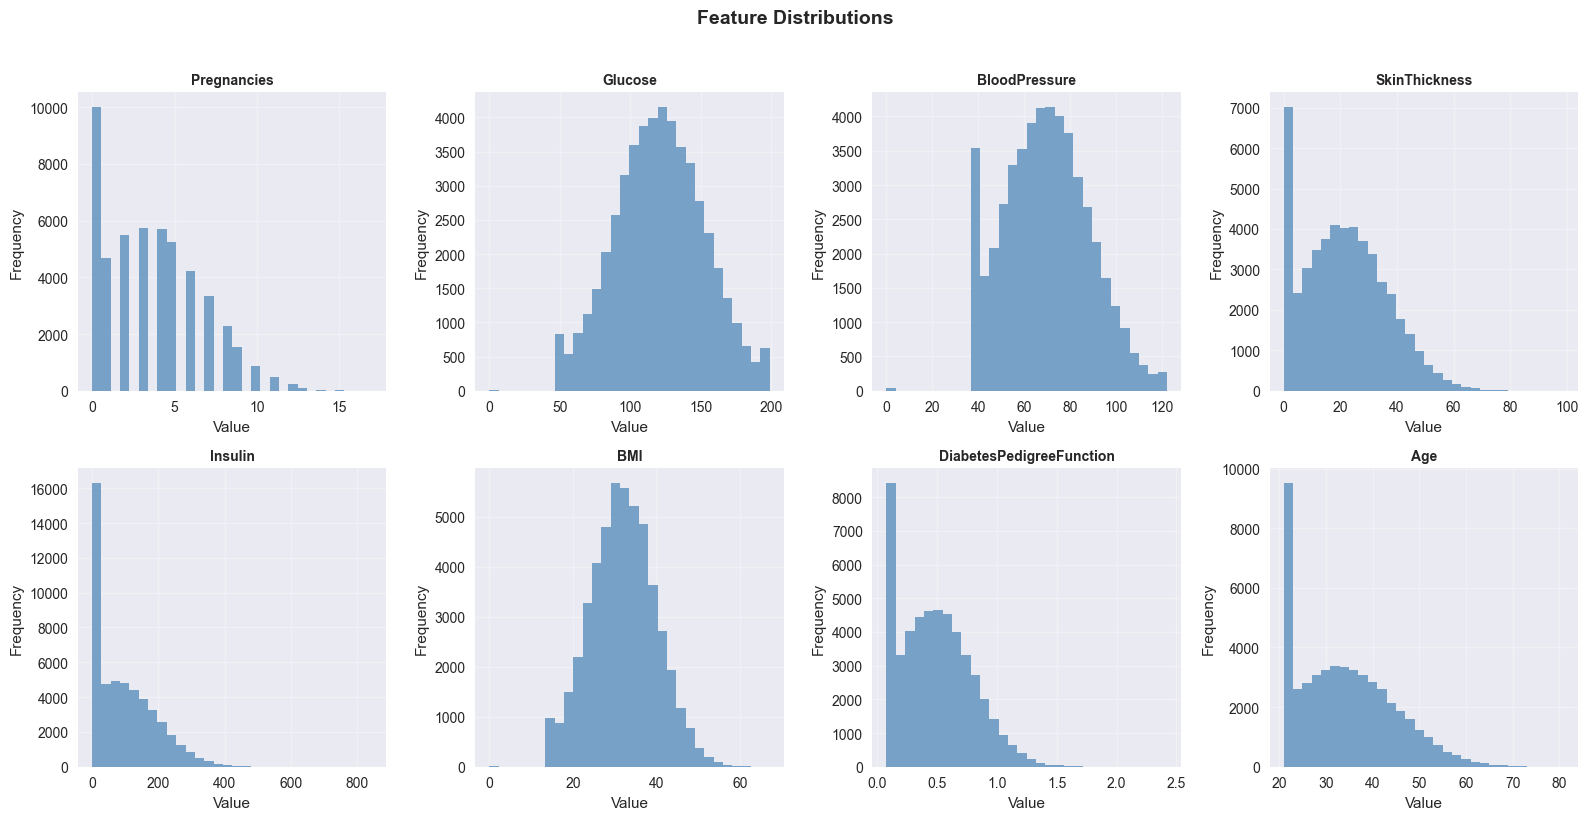

In [7]:
# EDA - Feature Distributions
if VISUALIZATION_AVAILABLE:
    fig, axes = plt.subplots(2, 4, figsize=(16, 8))
    axes = axes.ravel()
    
    features = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 
                'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']
    
    for i, feature in enumerate(features):
        df[feature].hist(bins=30, ax=axes[i], color='steelblue', alpha=0.7)
        axes[i].set_title(feature, fontsize=10, fontweight='bold')
        axes[i].set_xlabel('Value')
        axes[i].set_ylabel('Frequency')
        axes[i].grid(alpha=0.3)
    
    plt.suptitle('Feature Distributions', fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()


## Step 4: Data Preprocessing


In [8]:
# Create a copy for preprocessing
df_processed = df.copy()

print("="*70)
print("DATA PREPROCESSING")
print("="*70)

# Handle zero values (common in diabetes dataset)
print("\n1. Handling zero/missing values...")
zero_cols = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

for col in zero_cols:
    zero_count = (df_processed[col] == 0).sum()
    if zero_count > 0:
        median_val = df_processed[col][df_processed[col] > 0].median()
        if pd.notna(median_val):
            df_processed[col] = df_processed[col].replace(0, median_val)
            print(f"   {col}: Replaced {zero_count:,} zeros with median {median_val:.2f}")

print("\nSUCCESS: Zero values handled")


DATA PREPROCESSING

1. Handling zero/missing values...
   Glucose: Replaced 5 zeros with median 120.90
   BloodPressure: Replaced 35 zeros with median 69.30
   SkinThickness: Replaced 5,101 zeros with median 22.80
   Insulin: Replaced 12,239 zeros with median 114.40
   BMI: Replaced 11 zeros with median 32.00

SUCCESS: Zero values handled


In [9]:
# Prepare features and target
print("\n2. Preparing features and target...")

feature_cols = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 
                'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']

X = df_processed[feature_cols]
y = df_processed['Outcome']

print(f"   Features shape: {X.shape}")
print(f"   Target shape: {y.shape}")
print(f"   Feature columns: {feature_cols}")
print("\nSUCCESS: Features and target prepared")



2. Preparing features and target...
   Features shape: (50000, 8)
   Target shape: (50000,)
   Feature columns: ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']

SUCCESS: Features and target prepared


In [10]:
# Final data check
print("\n3. Final data check...")
print(f"   Missing values in X: {X.isnull().sum().sum()}")
print(f"   Missing values in y: {y.isnull().sum()}")
print(f"   Infinite values in X: {np.isinf(X.select_dtypes(include=[np.number])).sum().sum()}")
print("\nSUCCESS: Data preprocessing completed!")



3. Final data check...
   Missing values in X: 0
   Missing values in y: 0
   Infinite values in X: 0

SUCCESS: Data preprocessing completed!


## Step 5: Train-Test Split


In [11]:
# Split data into training and testing sets
print("="*70)
print("TRAIN-TEST SPLIT")
print("="*70)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42, 
    stratify=y  # Maintain class distribution
)

print(f"\nTraining set:")
print(f"   X_train shape: {X_train.shape}")
print(f"   y_train shape: {y_train.shape}")
print(f"   y_train distribution: {y_train.value_counts().to_dict()}")

print(f"\nTest set:")
print(f"   X_test shape: {X_test.shape}")
print(f"   y_test shape: {y_test.shape}")
print(f"   y_test distribution: {y_test.value_counts().to_dict()}")

print("\nSUCCESS: Train-test split completed!")


TRAIN-TEST SPLIT

Training set:
   X_train shape: (40000, 8)
   y_train shape: (40000,)
   y_train distribution: {0: 36925, 1: 3075}

Test set:
   X_test shape: (10000, 8)
   y_test shape: (10000,)
   y_test distribution: {0: 9231, 1: 769}

SUCCESS: Train-test split completed!


## Step 6: Model Training (Decision Tree)


In [12]:
# Initialize Decision Tree Classifier
print("="*70)
print("DECISION TREE MODEL TRAINING")
print("="*70)

# Decision Tree with optimized parameters
dt_model = DecisionTreeClassifier(
    max_depth=10,           # Limit tree depth to prevent overfitting
    min_samples_split=20,   # Minimum samples to split a node
    min_samples_leaf=10,    # Minimum samples in a leaf
    random_state=42,
    criterion='gini'        # Splitting criterion
)

print("\nModel Parameters:")
print(f"   Algorithm: Decision Tree Classifier")
print(f"   Max Depth: {dt_model.max_depth}")
print(f"   Min Samples Split: {dt_model.min_samples_split}")
print(f"   Min Samples Leaf: {dt_model.min_samples_leaf}")
print(f"   Criterion: {dt_model.criterion}")

print("\nTraining model...")
dt_model.fit(X_train, y_train)

print("\nSUCCESS: Model training completed!")


DECISION TREE MODEL TRAINING

Model Parameters:
   Algorithm: Decision Tree Classifier
   Max Depth: 10
   Min Samples Split: 20
   Min Samples Leaf: 10
   Criterion: gini

Training model...

SUCCESS: Model training completed!


## Step 7: Model Evaluation & Accuracy


In [13]:
# Make predictions
print("="*70)
print("MODEL EVALUATION")
print("="*70)

y_train_pred = dt_model.predict(X_train)
y_test_pred = dt_model.predict(X_test)

# Calculate accuracies
train_accuracy = accuracy_score(y_train, y_train_pred)
test_accuracy = accuracy_score(y_test, y_test_pred)

print(f"\nACCURACY RESULTS:")
print(f"   Training Accuracy: {train_accuracy:.4f} ({train_accuracy*100:.2f}%)")
print(f"   Test Accuracy:      {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")

# Check for overfitting
overfitting_gap = train_accuracy - test_accuracy
print(f"\n   Overfitting Gap:   {overfitting_gap:.4f}")

if overfitting_gap > 0.15:
    print("   WARNING: Potential overfitting detected!")
elif overfitting_gap < 0.05:
    print("   GOOD: Model generalizes well!")
else:
    print("   ACCEPTABLE: Model performance is reasonable")


MODEL EVALUATION

ACCURACY RESULTS:
   Training Accuracy: 0.9680 (96.80%)
   Test Accuracy:      0.9605 (96.05%)

   Overfitting Gap:   0.0075
   GOOD: Model generalizes well!


In [14]:
# Cross-Validation Score
print("\nCROSS-VALIDATION SCORE:")
cv_scores = cross_val_score(dt_model, X_train, y_train, cv=5, scoring='accuracy')
print(f"   CV Scores: {cv_scores}")
print(f"   Mean CV Accuracy: {cv_scores.mean():.4f} ({cv_scores.mean()*100:.2f}%)")
print(f"   Std CV Accuracy:  {cv_scores.std():.4f} (+/- {cv_scores.std()*2:.4f})")



CROSS-VALIDATION SCORE:
   CV Scores: [0.959625 0.959625 0.956125 0.958125 0.958125]
   Mean CV Accuracy: 0.9583 (95.83%)
   Std CV Accuracy:  0.0013 (+/- 0.0026)


In [15]:
# Classification Report
print("\nCLASSIFICATION REPORT (Test Set):")
print("="*70)
print(classification_report(y_test, y_test_pred, 
                          target_names=['No Diabetes', 'Diabetes']))



CLASSIFICATION REPORT (Test Set):
              precision    recall  f1-score   support

 No Diabetes       0.97      0.99      0.98      9231
    Diabetes       0.79      0.66      0.72       769

    accuracy                           0.96     10000
   macro avg       0.88      0.82      0.85     10000
weighted avg       0.96      0.96      0.96     10000




CONFUSION MATRIX (Test Set):
[[9100  131]
 [ 264  505]]


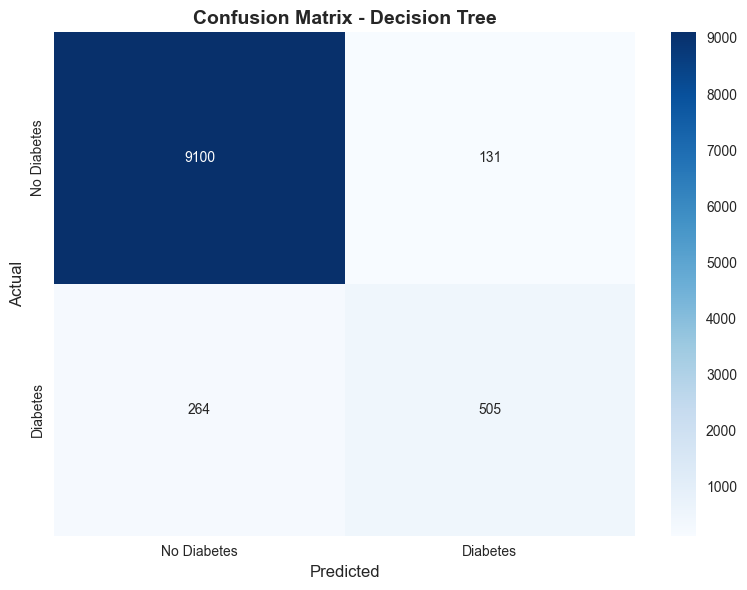


   True Negatives (TN):  9100
   False Positives (FP): 131
   False Negatives (FN): 264
   True Positives (TP):  505

   Precision: 0.7940
   Recall:    0.6567
   F1-Score:  0.7189


In [16]:
# Confusion Matrix
print("\nCONFUSION MATRIX (Test Set):")
print("="*70)
cm = confusion_matrix(y_test, y_test_pred)
print(cm)

if VISUALIZATION_AVAILABLE:
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=['No Diabetes', 'Diabetes'],
                yticklabels=['No Diabetes', 'Diabetes'])
    plt.title('Confusion Matrix - Decision Tree', fontsize=14, fontweight='bold')
    plt.ylabel('Actual', fontsize=12)
    plt.xlabel('Predicted', fontsize=12)
    plt.tight_layout()
    plt.show()

# Calculate metrics from confusion matrix
tn, fp, fn, tp = cm.ravel()
print(f"\n   True Negatives (TN):  {tn}")
print(f"   False Positives (FP): {fp}")
print(f"   False Negatives (FN): {fn}")
print(f"   True Positives (TP):  {tp}")

precision = tp / (tp + fp) if (tp + fp) > 0 else 0
recall = tp / (tp + fn) if (tp + fn) > 0 else 0
f1_score = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0

print(f"\n   Precision: {precision:.4f}")
print(f"   Recall:    {recall:.4f}")
print(f"   F1-Score:  {f1_score:.4f}")


In [17]:
# ROC-AUC Score
try:
    y_test_proba = dt_model.predict_proba(X_test)[:, 1]
    roc_auc = roc_auc_score(y_test, y_test_proba)
    print(f"\nROC-AUC SCORE:")
    print(f"   ROC-AUC: {roc_auc:.4f} ({roc_auc*100:.2f}%)")
except Exception as e:
    print(f"\nWARNING: Could not calculate ROC-AUC: {e}")



ROC-AUC SCORE:
   ROC-AUC: 0.9617 (96.17%)


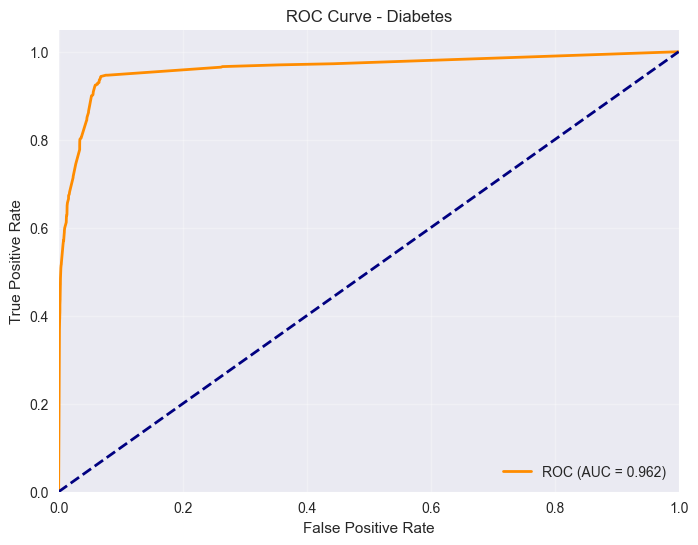

Best threshold (Youden Index): 0.0588


In [18]:
# ROC Curve + Youden Index (Best Threshold)
from sklearn.metrics import roc_curve, auc

# Ensure y_test_proba exists (from ROC-AUC cell or compute here)
if 'y_test_proba' not in dir():
    y_test_proba = dt_model.predict_proba(X_test)[:, 1]

fpr, tpr, thresholds = roc_curve(y_test, y_test_proba)
roc_auc_val = auc(fpr, tpr)

if VISUALIZATION_AVAILABLE:
    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC (AUC = {roc_auc_val:.3f})')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    plt.xlim([0.0, 1.0]); plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate')
    plt.title('ROC Curve - Diabetes'); plt.legend(loc='lower right'); plt.grid(alpha=0.3); plt.show()

youden_idx = np.argmax(tpr - fpr)
best_threshold = float(thresholds[youden_idx])
print(f"Best threshold (Youden Index): {best_threshold:.4f}")

## Step 8: Save Model


In [19]:
# Save the trained model + threshold.json
import json

print("="*70)
print("SAVING MODEL")
print("="*70)

os.makedirs('../backend/ml_models', exist_ok=True)
model_path = '../backend/ml_models/diabetes_model.pkl'
threshold_path = '../backend/ml_models/threshold.json'

joblib.dump(dt_model, model_path)

thresh_data = {}
if os.path.exists(threshold_path):
    with open(threshold_path) as f:
        thresh_data = json.load(f)
thresh_data["diabetes"] = best_threshold
with open(threshold_path, "w") as f:
    json.dump(thresh_data, f, indent=2)

print(f"\nSUCCESS: Model saved successfully!")
print(f"   Path: {model_path}")
print(f"   Threshold: {threshold_path} (diabetes={best_threshold:.4f})")
print(f"   Model Type: Decision Tree Classifier")
print(f"   Test Accuracy: {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")

print("\n" + "="*70)
print("TRAINING COMPLETED SUCCESSFULLY!")
print("="*70)


SAVING MODEL

SUCCESS: Model saved successfully!
   Path: ../backend/ml_models/diabetes_model.pkl
   Threshold: ../backend/ml_models/threshold.json (diabetes=0.0588)
   Model Type: Decision Tree Classifier
   Test Accuracy: 0.9605 (96.05%)

TRAINING COMPLETED SUCCESSFULLY!
